# Notebook 05 — Preparación de Datos y Modelado ML

**Proyecto:** Sistema de Predicción y Clasificación de la Desnutrición en niños menores de cinco años  
**Fase CRISP-DM:** 3 (Preparación) + 4 (Modelado)  
**Dataset:** `dataset_ml.csv` (generado por notebook 03)  
**Variable objetivo:** `clas_peso`

---
## Contenido
### Parte 1 — Preparación de datos
1. Carga e inspección
2. Ingeniería de features — selección y descarte justificado
3. Codificación de variables categóricas
4. Imputación de nulos residuales
5. Escalado — RobustScaler selectivo
6. División train/test estratificada
7. Balanceo de clases — SMOTE

### Parte 2 — Modelado
8. Entrenamiento de modelos — **Modelo A (con IMC)**
9. Comparativa de métricas — Modelo A
10. Matriz de confusión — Modelo A
11. Feature importance — Modelo A
12. **Modelo B — Sin IMC (contexto rural / atención primaria)**
13. Comparativa final: Modelo A vs Modelo B
14. Conclusiones y modelo seleccionado

---
# PARTE 1 — Preparación de datos

## 1. Carga e inspección

In [1]:
import sys
!{sys.executable} -m pip install imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from imblearn.over_sampling import SMOTE

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3})

CLASES     = ['Desnut. severa', 'Desnut. moderada', 'Normal bajo',
              'Normal', 'Sobrepeso', 'Obesidad']
COLORES    = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#2980b9', '#8e44ad']

df_raw = pd.read_csv('../data/processed/dataset_ml.csv')
print(f'Shape original : {df_raw.shape}')
print(f'Columnas       : {list(df_raw.columns)}')
print(f'\nclas_peso distribución:')
print(df_raw['clas_peso'].value_counts().sort_index())

Shape original : (2448, 53)
Columnas       : ['anio', 'edad_', 'uni_med_', 'sexo_', 'nacionali_', 'per_etn_', 'estrato_', 'cod_pais_o', 'cod_dpto_o', 'cod_mun_o', 'area_', 'cod_pais_r', 'cod_dpto_r', 'cod_mun_r', 'ndep_resi', 'nmun_resi', 'tip_ss_', 'niv_educat', 'menores', 'gp_desplaz', 'gp_migrant', 'gp_indigen', 'gp_pobicbf', 'gp_mad_com', 'gp_vic_vio', 'gp_gestan', 'ocupacion_', 'peso_nac', 'talla_nac', 'edad_ges', 't_lechem', 'e_complem', 'crec_dllo', 'esq_vac', 'carne_vac', 'peso_act', 'talla_act', 'per_braqui', 'imc', 'clas_peso', 'clas_talla', 'edema', 'delgadez', 'palidez', 'piel_rese', 'hiperpigm', 'cambios_cabello', 'ruta_atenc', 'tipo_manej', 'pac_hos_', 'con_fin_', 'tip_cas_', 'fuente_']

clas_peso distribución:
clas_peso
1.0     379
2.0    1730
3.0     133
4.0     167
5.0      24
6.0       6
Name: count, dtype: int64


## 2. Ingeniería de features — selección y descarte justificado

Se parte de las 53 columnas del `dataset_ml.csv` y se reduce a un set limpio de features,
eliminando columnas por razones metodológicas documentadas.

> **Nota sobre el IMC:** Se desarrollan **dos versiones del modelo**:
> - **Modelo A (con IMC):** para clínicas y hospitales con báscula y tallímetro.
>   El IMC es una medida clínica estándar calculable en el momento de la consulta (peso/talla²).
>   A diferencia de `zscore_pt`, no requiere tablas de referencia OMS ni define directamente `clas_peso`.
> - **Modelo B (sin IMC):** para promotores de salud en zonas rurales sin equipo completo.
>   Solo requiere cinta métrica para el perímetro braquial. Más útil para detección temprana en campo.

In [2]:
# ── Eliminar clas_peso nulos (9 registros) ────────────────────────────────
df = df_raw.dropna(subset=['clas_peso']).copy()
df['clas_peso'] = df['clas_peso'].astype(int)

# ── Crear edad_meses (más informativa que edad_ + uni_med_ por separado) ──
df['edad_meses'] = df.apply(
    lambda r: r['edad_'] * 12 if r['uni_med_'] == 1 else r['edad_'], axis=1
)

# ── Columnas a eliminar y justificación ───────────────────────────────────
DESCARTAR = {
    'talla_act'   : 'Multicolinealidad con peso_act (r=0.95) — aporta información redundante',
    'talla_nac'   : '61% nulos — no es imputable de forma fiable',
    'anio'        : 'Variable temporal administrativa, no feature del paciente',
    'edad_'       : 'Reemplazada por edad_meses (más precisa)',
    'uni_med_'    : 'Solo necesaria para calcular edad_meses, ya creada',
    'nacionali_'  : 'Redundante con cod_pais_o y per_etn_',
    'cod_pais_o'  : 'Redundante con per_etn_ y area_',
    'cod_pais_r'  : 'Redundante',
    'cod_mun_o'   : 'Alta cardinalidad (36 municipios) — usar departamento',
    'cod_mun_r'   : 'Alta cardinalidad (39 municipios)',
    'nmun_resi'   : 'Alta cardinalidad (44 valores) — texto libre',
    'cod_dpto_r'  : 'Redundante con cod_dpto_o',
    'ndep_resi'   : 'Texto — reemplazado por cod_dpto_o codificado',
    'tip_ss_'     : '97% del mismo valor (S=subsidiado) — sin variabilidad',
    'gp_desplaz'  : 'Solo 9 casos positivos — sin variabilidad estadística',
    'gp_migrant'  : 'Solo 10 casos positivos',
    'gp_indigen'  : 'Solo 1 caso positivo',
    'gp_vic_vio'  : 'Solo 1 caso positivo',
    'gp_mad_com'  : 'Todos el mismo valor (2) — sin variabilidad',
    'gp_gestan'   : 'Todos el mismo valor (2) — sin variabilidad',
    'tipo_manej'  : '178 nulos + redundante con ruta_atenc',
    'con_fin_'    : 'Variable de resultado — no disponible al momento de predecir',
    'pac_hos_'    : 'Variable de resultado — no disponible al momento de predecir',
    'fuente_'     : 'Variable administrativa',
    'tip_cas_'    : 'Variable administrativa',
    # NOTA: zscore_pt y zscore_te ya fueron excluidos en el notebook 03 (data leakage puro)
    # NOTA: imc se mantiene en Modelo A — es calculable en consulta (peso/talla²)
    #        y se excluye en Modelo B para simular contexto rural sin equipos completos
}

print('Columnas descartadas y justificación:')
for col, razon in DESCARTAR.items():
    print(f'  {col:20s}: {razon}')

# ── Features Modelo A — CON IMC ───────────────────────────────────────────
FEATURES_A = [
    'edad_meses', 'per_etn_', 'estrato_',
    'area_', 'cod_dpto_o',
    'niv_educat', 'menores', 'gp_pobicbf',
    'peso_nac', 'edad_ges',
    'peso_act', 'per_braqui', 'imc',        # ← imc incluido
    't_lechem', 'e_complem',
    'crec_dllo', 'esq_vac', 'carne_vac',
    'edema', 'delgadez', 'palidez',
    'piel_rese', 'hiperpigm', 'cambios_cabello',
    'ruta_atenc',
]

# ── Features Modelo B — SIN IMC ───────────────────────────────────────────
FEATURES_B = [f for f in FEATURES_A if f != 'imc']

faltantes = [f for f in FEATURES_A if f not in df.columns]
print(f'\nFeatures faltantes: {faltantes if faltantes else "Ninguno ✅"}')
print(f'Modelo A (con IMC) : {len(FEATURES_A)} features')
print(f'Modelo B (sin IMC) : {len(FEATURES_B)} features')

Columnas descartadas y justificación:
  talla_act           : Multicolinealidad con peso_act (r=0.95) — aporta información redundante
  talla_nac           : 61% nulos — no es imputable de forma fiable
  anio                : Variable temporal administrativa, no feature del paciente
  edad_               : Reemplazada por edad_meses (más precisa)
  uni_med_            : Solo necesaria para calcular edad_meses, ya creada
  nacionali_          : Redundante con cod_pais_o y per_etn_
  cod_pais_o          : Redundante con per_etn_ y area_
  cod_pais_r          : Redundante
  cod_mun_o           : Alta cardinalidad (36 municipios) — usar departamento
  cod_mun_r           : Alta cardinalidad (39 municipios)
  nmun_resi           : Alta cardinalidad (44 valores) — texto libre
  cod_dpto_r          : Redundante con cod_dpto_o
  ndep_resi           : Texto — reemplazado por cod_dpto_o codificado
  tip_ss_             : 97% del mismo valor (S=subsidiado) — sin variabilidad
  gp_desplaz         

## 3. Codificación de variables categóricas

- **`cod_dpto_o`** — viene como string (`'20'`, `'44'`, `'D0'`). Se aplica **Label Encoding**
  porque es ordinal implícito y tiene baja cardinalidad (9 valores únicos).
- El resto de variables categóricas ya son numéricas en el dataset.

In [3]:
# Preparar df_model base (aplica a ambos modelos)
df_model = df[FEATURES_A + ['clas_peso']].copy()

# Label Encoding para cod_dpto_o (string → entero)
le_dpto = LabelEncoder()
df_model['cod_dpto_o'] = le_dpto.fit_transform(df_model['cod_dpto_o'].astype(str))

print('Codificación cod_dpto_o:')
for codigo, etiqueta in zip(le_dpto.classes_, le_dpto.transform(le_dpto.classes_)):
    print(f'  {codigo} → {etiqueta}')

print(f'\nDtypes resultantes:')
print(df_model.dtypes.to_string())

Codificación cod_dpto_o:
  11 → 0
  15 → 1
  20 → 2
  25 → 3
  44 → 4
  47 → 5
  52 → 6
  68 → 7
  D0 → 8

Dtypes resultantes:
edad_meses           int64
per_etn_             int64
estrato_             int64
area_                int64
cod_dpto_o           int64
niv_educat         float64
menores            float64
gp_pobicbf         float64
peso_nac           float64
edad_ges           float64
peso_act           float64
per_braqui         float64
imc                float64
t_lechem           float64
e_complem          float64
crec_dllo            int64
esq_vac              int64
carne_vac            int64
edema                int64
delgadez             int64
palidez              int64
piel_rese            int64
hiperpigm            int64
cambios_cabello      int64
ruta_atenc           int64
clas_peso            int64


## 4. Imputación de nulos residuales

Solo 3 features tienen nulos residuales tras el ETL:
- `niv_educat` (33 nulos) → mediana
- `gp_pobicbf` (2 nulos) → valor por defecto 2 (No)
- `per_braqui` (227 nulos, ~9%) → mediana por `clas_peso` (imputación estratificada)

In [4]:
print('Nulos antes de imputación:')
nulos = df_model.isnull().sum()
print(nulos[nulos > 0].to_string())

# niv_educat: mediana global
med_edu = df_model['niv_educat'].median()
df_model['niv_educat'] = df_model['niv_educat'].fillna(med_edu)
print(f'\nniv_educat: imputado con mediana = {med_edu}')

# gp_pobicbf: 2 = No (valor por defecto)
df_model['gp_pobicbf'] = df_model['gp_pobicbf'].fillna(2)
print('gp_pobicbf: 2 nulos → 2 (No)')

# menores: mediana global
df_model['menores'] = df_model['menores'].fillna(df_model['menores'].median())

# per_braqui: mediana estratificada por clas_peso
df_model['per_braqui'] = df_model.groupby('clas_peso')['per_braqui'].transform(
    lambda x: x.fillna(x.median())
)
df_model['per_braqui'] = df_model['per_braqui'].fillna(df_model['per_braqui'].median())
print('per_braqui: imputado con mediana estratificada por clas_peso')

print(f'\nNulos después de imputación: {df_model.isnull().sum().sum()} ✅')

Nulos antes de imputación:
niv_educat     33
gp_pobicbf      2
per_braqui    227

niv_educat: imputado con mediana = 3.0
gp_pobicbf: 2 nulos → 2 (No)
per_braqui: imputado con mediana estratificada por clas_peso

Nulos después de imputación: 0 ✅


## 5. Escalado — RobustScaler selectivo

Se aplica **RobustScaler** solo a las variables que resultaron NO normales en las pruebas
de normalidad del notebook 04 (sección 12). Las variables ya normales no se tocan.

**¿Por qué RobustScaler y no StandardScaler?**  
Porque usa la mediana y el rango intercuartílico en lugar de la media y desviación estándar,
lo que lo hace resistente a los outliers que vimos en los boxplots del notebook 04.

In [5]:
# Variables NO normales → escalar (aplica a ambos modelos)
COLS_ESCALAR = ['peso_act', 'per_braqui', 't_lechem', 'menores',
                'peso_nac', 'edad_meses', 'imc', 'edad_ges', 'e_complem']

# ── Modelo A — con IMC ────────────────────────────────────────────────────
X_A = df_model[FEATURES_A].copy()
y   = df_model['clas_peso'].copy()

scaler_A = RobustScaler()
cols_esc_A = [c for c in COLS_ESCALAR if c in FEATURES_A]
X_A[cols_esc_A] = scaler_A.fit_transform(X_A[cols_esc_A])

# ── Modelo B — sin IMC ────────────────────────────────────────────────────
X_B = df_model[FEATURES_B].copy()

scaler_B = RobustScaler()
cols_esc_B = [c for c in COLS_ESCALAR if c in FEATURES_B]
X_B[cols_esc_B] = scaler_B.fit_transform(X_B[cols_esc_B])

print('Escalado aplicado:')
print(f'  Modelo A ({len(FEATURES_A)} features): {cols_esc_A}')
print(f'  Modelo B ({len(FEATURES_B)} features): {cols_esc_B}')
print(f'\nShape X_A: {X_A.shape}')
print(f'Shape X_B: {X_B.shape}')

Escalado aplicado:
  Modelo A (25 features): ['peso_act', 'per_braqui', 't_lechem', 'menores', 'peso_nac', 'edad_meses', 'imc', 'edad_ges', 'e_complem']
  Modelo B (24 features): ['peso_act', 'per_braqui', 't_lechem', 'menores', 'peso_nac', 'edad_meses', 'edad_ges', 'e_complem']

Shape X_A: (2439, 25)
Shape X_B: (2439, 24)


## 6. División train/test estratificada

Se usa **stratify=y** para garantizar que la proporción de cada clase de desnutrición
sea la misma en train y test. Sin esto, las clases minoritarias (Sobrepeso, Obesidad)
podrían quedar subrepresentadas en el conjunto de prueba.

In [6]:
# Split estratificado — Modelo A
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y, test_size=0.2, random_state=42, stratify=y
)

# Split estratificado — Modelo B (mismo índice para comparación justa)
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train_A.shape[0]:,} registros (80%)')
print(f'Test  : {X_test_A.shape[0]:,} registros (20%)')
print(f'\nDistribución de clases en train:')
print(y_train_A.value_counts().sort_index().rename('Train'))
print(f'\nDistribución de clases en test:')
print(y_test_A.value_counts().sort_index().rename('Test'))

Train : 1,951 registros (80%)
Test  : 488 registros (20%)

Distribución de clases en train:
clas_peso
1     303
2    1384
3     106
4     134
5      19
6       5
Name: Train, dtype: int64

Distribución de clases en test:
clas_peso
1     76
2    346
3     27
4     33
5      5
6      1
Name: Test, dtype: int64


## 7. Balanceo de clases — SMOTE

El dataset tiene un desbalance severo: >85% de los casos son desnutrición.
Las clases Sobrepeso (24 casos) y Obesidad (6 casos) son muy minoritarias.

**SMOTE** (Synthetic Minority Over-sampling Technique) genera ejemplos sintéticos
de las clases minoritarias interpolando entre casos reales existentes.

**Importante:** SMOTE se aplica **solo al conjunto de entrenamiento**, nunca al test.
Aplicarlo al test contaminaría la evaluación.

Distribución ANTES de SMOTE (train):
clas_peso
1     303
2    1384
3     106
4     134
5      19
6       5

Distribución DESPUÉS de SMOTE:
clas_peso
1    1384
2    1384
3    1384
4    1384
5    1384
6    1384

Tamaño train original : 1,951
Tamaño train con SMOTE: 8,304


  File "c:\Users\yorie\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\yorie\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\yorie\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\yorie\anaconda3\Lib\subprocess.

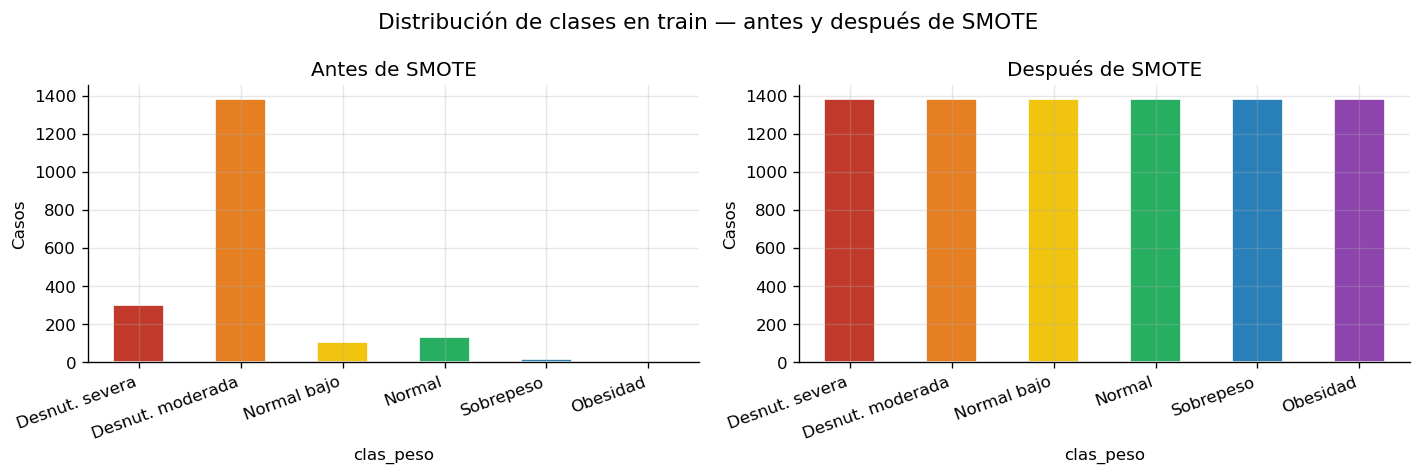

In [7]:
smote = SMOTE(random_state=42, k_neighbors=3)

X_train_A_sm, y_train_A_sm = smote.fit_resample(X_train_A, y_train_A)
X_train_B_sm, y_train_B_sm = smote.fit_resample(X_train_B, y_train_B)

print('Distribución ANTES de SMOTE (train):')
print(y_train_A.value_counts().sort_index().to_string())
print(f'\nDistribución DESPUÉS de SMOTE:')
print(pd.Series(y_train_A_sm).value_counts().sort_index().to_string())
print(f'\nTamaño train original : {len(y_train_A):,}')
print(f'Tamaño train con SMOTE: {len(y_train_A_sm):,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_train_A.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=COLORES, edgecolor='white')
axes[0].set_title('Antes de SMOTE', fontsize=12)
axes[0].set_xticklabels(CLASES, rotation=20, ha='right')
axes[0].set_ylabel('Casos')

pd.Series(y_train_A_sm).value_counts().sort_index().plot(kind='bar', ax=axes[1], color=COLORES, edgecolor='white')
axes[1].set_title('Después de SMOTE', fontsize=12)
axes[1].set_xticklabels(CLASES, rotation=20, ha='right')
axes[1].set_ylabel('Casos')
plt.suptitle('Distribución de clases en train — antes y después de SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

---
# PARTE 2 — Modelado

## 8. Entrenamiento de modelos — Modelo A (con IMC)

Se entrenan 4 modelos con los **26 features incluyendo IMC**:

| Modelo | Tipo | Razón de inclusión |
|---|---|---|
| Logistic Regression | Lineal | Baseline — modelo simple de referencia |
| Random Forest | Ensamble de árboles | Robusto, maneja bien variables mixtas |
| Gradient Boosting | Ensamble boosting | Generalmente el mejor en datos tabulares |
| SVM | Kernel | Efectivo en espacios de alta dimensión |

In [8]:
MODELOS_DEF = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=None, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=4, random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', class_weight='balanced',
        C=10, gamma='scale', probability=True, random_state=42
    ),
}

modelos_A = {}
for nombre, modelo in MODELOS_DEF.items():
    print(f'Entrenando {nombre} (Modelo A)...', end=' ')
    modelo.fit(X_train_A_sm, y_train_A_sm)
    modelos_A[nombre] = modelo
    print('✅')

Entrenando Logistic Regression (Modelo A)... ✅
Entrenando Random Forest (Modelo A)... ✅
Entrenando Gradient Boosting (Modelo A)... ✅
Entrenando SVM (Modelo A)... ✅


## 9. Comparativa de métricas — Modelo A (con IMC)

- **F1-weighted**: métrica principal — pondera por frecuencia de clase
- **F1-macro**: sin ponderar — penaliza errores en clases minoritarias
- **Recall-D.severa**: % de casos severos correctamente detectados — crítico en salud pública


Modelo A (con IMC) — comparativa de métricas
             Modelo  Accuracy  F1-weighted  F1-macro  F1-Desnut.severa  Recall-D.severa
  Gradient Boosting    0.8648       0.8645    0.7420            0.7183           0.6711
      Random Forest    0.8627       0.8611    0.7751            0.6853           0.6447
                SVM    0.8402       0.8391    0.5692            0.6351           0.6184
Logistic Regression    0.7889       0.7981    0.4713            0.6463           0.6974


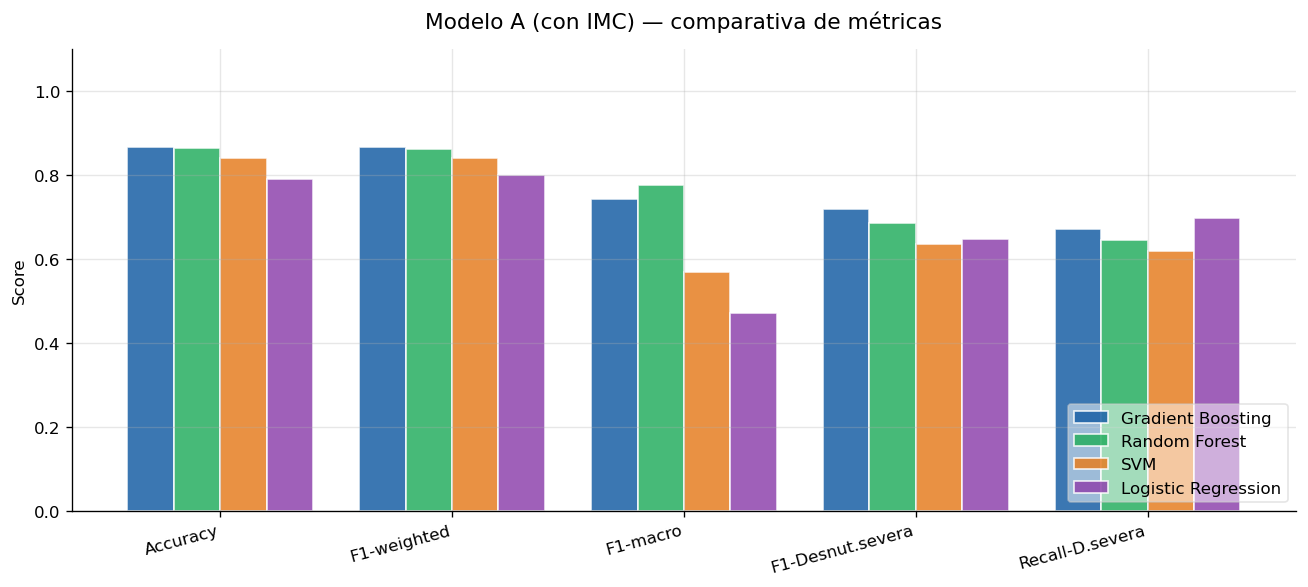

In [9]:
def evaluar_modelos(modelos, X_test, y_test, titulo):
    resultados = []
    predicciones = {}
    for nombre, modelo in modelos.items():
        y_pred = modelo.predict(X_test)
        predicciones[nombre] = y_pred
        acc   = (y_pred == y_test).mean()
        f1_w  = f1_score(y_test, y_pred, average='weighted')
        f1_m  = f1_score(y_test, y_pred, average='macro')
        f1_c1 = f1_score(y_test, y_pred, labels=[1], average='macro')
        rec_c1 = (y_pred[y_test == 1] == 1).mean() if (y_test == 1).sum() > 0 else 0
        resultados.append({
            'Modelo'          : nombre,
            'Accuracy'        : round(acc,   4),
            'F1-weighted'     : round(f1_w,  4),
            'F1-macro'        : round(f1_m,  4),
            'F1-Desnut.severa': round(f1_c1, 4),
            'Recall-D.severa' : round(rec_c1, 4),
        })
    df_res = pd.DataFrame(resultados).sort_values('F1-weighted', ascending=False)

    print(f'\n{titulo}')
    print(df_res.to_string(index=False))

    fig, ax = plt.subplots(figsize=(11, 5))
    metricas = ['Accuracy','F1-weighted','F1-macro','F1-Desnut.severa','Recall-D.severa']
    x = np.arange(len(metricas))
    width = 0.2
    colores_mod = ['#185fa5','#27ae60','#e67e22','#8e44ad']
    for i, (_, row) in enumerate(df_res.iterrows()):
        vals = [row[m] for m in metricas]
        ax.bar(x + i*width, vals, width, label=row['Modelo'],
               color=colores_mod[i], edgecolor='white', alpha=0.85)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(metricas, rotation=15, ha='right')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.set_title(titulo, fontsize=13, pad=12)
    ax.legend(loc='lower right', framealpha=0.5)
    plt.tight_layout()
    plt.show()
    return df_res, predicciones

df_res_A, preds_A = evaluar_modelos(modelos_A, X_test_A, y_test_A,
                                     'Modelo A (con IMC) — comparativa de métricas')

In [10]:
for nombre, y_pred in preds_A.items():
    print(f'\n{"="*55}')
    print(f'  {nombre} — Modelo A (con IMC)')
    print(f'{"="*55}')
    print(classification_report(y_test_A, y_pred, target_names=CLASES, zero_division=0))


  Logistic Regression — Modelo A (con IMC)
                  precision    recall  f1-score   support

  Desnut. severa       0.60      0.70      0.65        76
Desnut. moderada       0.93      0.86      0.89       346
     Normal bajo       0.41      0.59      0.48        27
          Normal       0.57      0.52      0.54        33
       Sobrepeso       0.20      0.40      0.27         5
        Obesidad       0.00      0.00      0.00         1

        accuracy                           0.79       488
       macro avg       0.45      0.51      0.47       488
    weighted avg       0.81      0.79      0.80       488


  Random Forest — Modelo A (con IMC)
                  precision    recall  f1-score   support

  Desnut. severa       0.73      0.64      0.69        76
Desnut. moderada       0.91      0.92      0.92       346
     Normal bajo       0.62      0.74      0.68        27
          Normal       0.83      0.91      0.87        33
       Sobrepeso       0.67      0.40      0

## 10. Matriz de confusión — Modelo A (con IMC)

- Diagonal principal → predicciones correctas
- Fuera de la diagonal → errores
- El error más crítico: confundir **Desnutrición severa** con moderada

Mejor modelo A: Gradient Boosting | F1-weighted: 0.8645


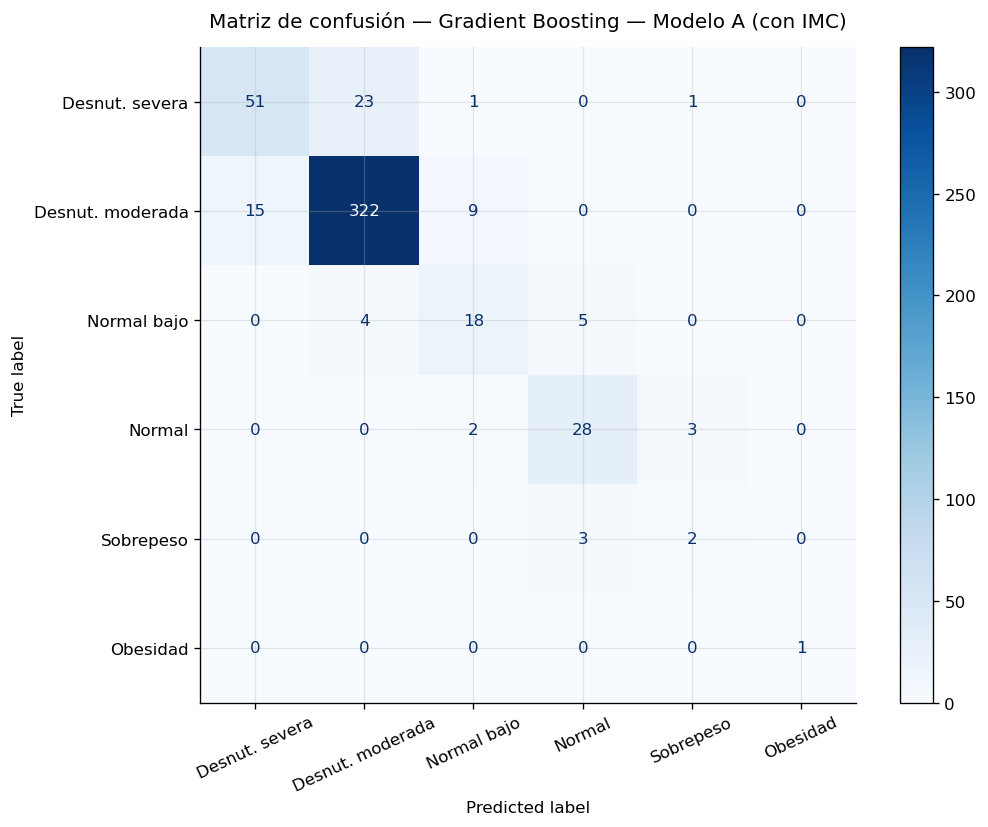


Desnutrición severa — Modelo A:
  Casos reales     : 76
  Detectados       : 51 (67.1%)
  No detectados FN : 25 (32.9%)


In [11]:
mejor_A = df_res_A.iloc[0]['Modelo']
y_pred_mejor_A = preds_A[mejor_A]

print(f'Mejor modelo A: {mejor_A} | F1-weighted: {df_res_A.iloc[0]["F1-weighted"]:.4f}')

cm_A = confusion_matrix(y_test_A, y_pred_mejor_A)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_A, display_labels=CLASES).plot(
    ax=ax, cmap='Blues', colorbar=True, xticks_rotation=25)
ax.set_title(f'Matriz de confusión — {mejor_A} — Modelo A (con IMC)', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

total_severos = (y_test_A == 1).sum()
detectados_A  = cm_A[0, 0]
print(f'\nDesnutrición severa — Modelo A:')
print(f'  Casos reales     : {total_severos}')
print(f'  Detectados       : {detectados_A} ({detectados_A/total_severos*100:.1f}%)')
print(f'  No detectados FN : {total_severos - detectados_A} ({(total_severos-detectados_A)/total_severos*100:.1f}%)')

## 11. Feature importance — Modelo A (con IMC)

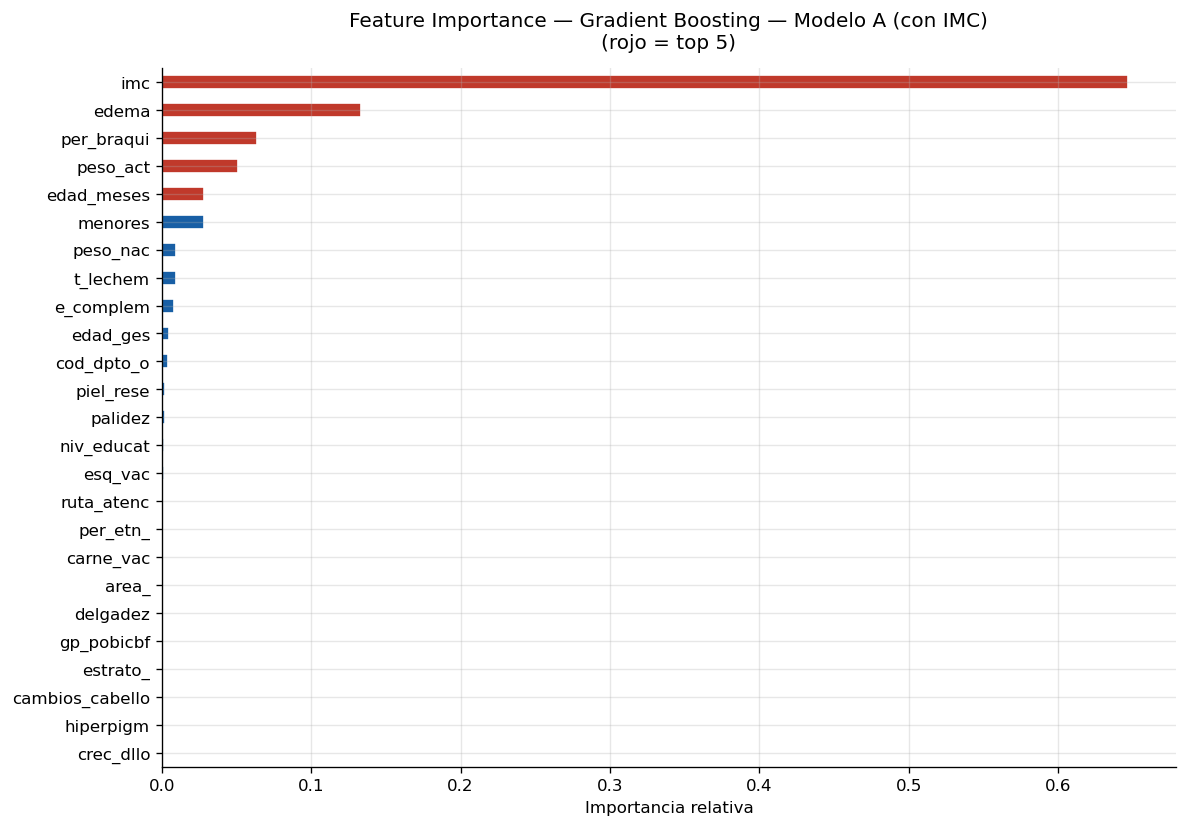

imc                0.6466
edema              0.1332
per_braqui         0.0638
peso_act           0.0509
edad_meses         0.0285
menores            0.0279
peso_nac           0.0096
t_lechem           0.0092
e_complem          0.0082
edad_ges           0.0051
cod_dpto_o         0.0040
piel_rese          0.0024
palidez            0.0019
niv_educat         0.0018
esq_vac            0.0012
ruta_atenc         0.0010
per_etn_           0.0008
carne_vac          0.0007
area_              0.0007
delgadez           0.0007
gp_pobicbf         0.0006
estrato_           0.0004
cambios_cabello    0.0003
hiperpigm          0.0002
crec_dllo          0.0002


In [12]:
modelo_mejor_A = modelos_A[mejor_A]

if hasattr(modelo_mejor_A, 'feature_importances_'):
    imp_A = pd.Series(modelo_mejor_A.feature_importances_, index=FEATURES_A)
elif hasattr(modelo_mejor_A, 'coef_'):
    imp_A = pd.Series(np.abs(modelo_mejor_A.coef_).mean(axis=0), index=FEATURES_A)
else:
    rf_A = modelos_A.get('Random Forest')
    imp_A = pd.Series(rf_A.feature_importances_, index=FEATURES_A)

imp_A = imp_A.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colores_fi = ['#c0392b' if i < 5 else '#185fa5' if i < 15 else '#95a5a6'
              for i in range(len(imp_A))]
imp_A[::-1].plot(kind='barh', ax=ax, color=colores_fi[::-1], edgecolor='white')
ax.set_title(f'Feature Importance — {mejor_A} — Modelo A (con IMC)\n(rojo = top 5)',
             fontsize=12, pad=12)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()
print(imp_A.round(4).to_string())

In [13]:
print('Comparativa ANOVA (notebook 04) vs Feature Importance Modelo A:')
print('='*65)
anova_f = {
    'per_braqui': 87.87, 'peso_act': 55.36, 'imc': '⚠️ (parcial)',
    't_lechem': 11.37, 'niv_educat': 9.83, 'edad_meses': 5.85,
    'area_': 4.77, 'peso_nac': 4.50, 'menores': 1.83, 'estrato_': 1.75
}
for var, f_val in anova_f.items():
    if var in imp_A.index:
        imp = imp_A[var]
        print(f'{var:20s}  ANOVA-F: {str(f_val):12s}  Importancia: {imp:.4f}')

Comparativa ANOVA (notebook 04) vs Feature Importance Modelo A:
per_braqui            ANOVA-F: 87.87         Importancia: 0.0638
peso_act              ANOVA-F: 55.36         Importancia: 0.0509
imc                   ANOVA-F: ⚠️ (parcial)  Importancia: 0.6466
t_lechem              ANOVA-F: 11.37         Importancia: 0.0092
niv_educat            ANOVA-F: 9.83          Importancia: 0.0018
edad_meses            ANOVA-F: 5.85          Importancia: 0.0285
area_                 ANOVA-F: 4.77          Importancia: 0.0007
peso_nac              ANOVA-F: 4.5           Importancia: 0.0096
menores               ANOVA-F: 1.83          Importancia: 0.0279
estrato_              ANOVA-F: 1.75          Importancia: 0.0004


---
## 12. Modelo B — Sin IMC (contexto rural / atención primaria)

**¿Por qué un modelo sin IMC?**

El IMC requiere báscula y tallímetro calibrados. En zonas rurales dispersas del Cesar
y La Guajira, los promotores de salud a menudo solo disponen de una cinta métrica.

Este modelo usa las mismas variables excepto `imc`, y evalúa si sigue siendo útil
para la detección temprana en campo con recursos limitados.

In [14]:
import copy

modelos_B = {}
for nombre, modelo_orig in MODELOS_DEF.items():
    modelo_b = copy.deepcopy(modelo_orig)
    print(f'Entrenando {nombre} (Modelo B)...', end=' ')
    modelo_b.fit(X_train_B_sm, y_train_B_sm)
    modelos_B[nombre] = modelo_b
    print('✅')

Entrenando Logistic Regression (Modelo B)... ✅
Entrenando Random Forest (Modelo B)... ✅
Entrenando Gradient Boosting (Modelo B)... ✅
Entrenando SVM (Modelo B)... ✅



Modelo B (sin IMC) — comparativa de métricas
             Modelo  Accuracy  F1-weighted  F1-macro  F1-Desnut.severa  Recall-D.severa
  Gradient Boosting    0.7725       0.7603    0.5102            0.4361           0.3816
      Random Forest    0.7602       0.7558    0.5619            0.4507           0.4211
                SVM    0.7336       0.7321    0.3639            0.4304           0.4474
Logistic Regression    0.6865       0.7064    0.4600            0.4607           0.5395


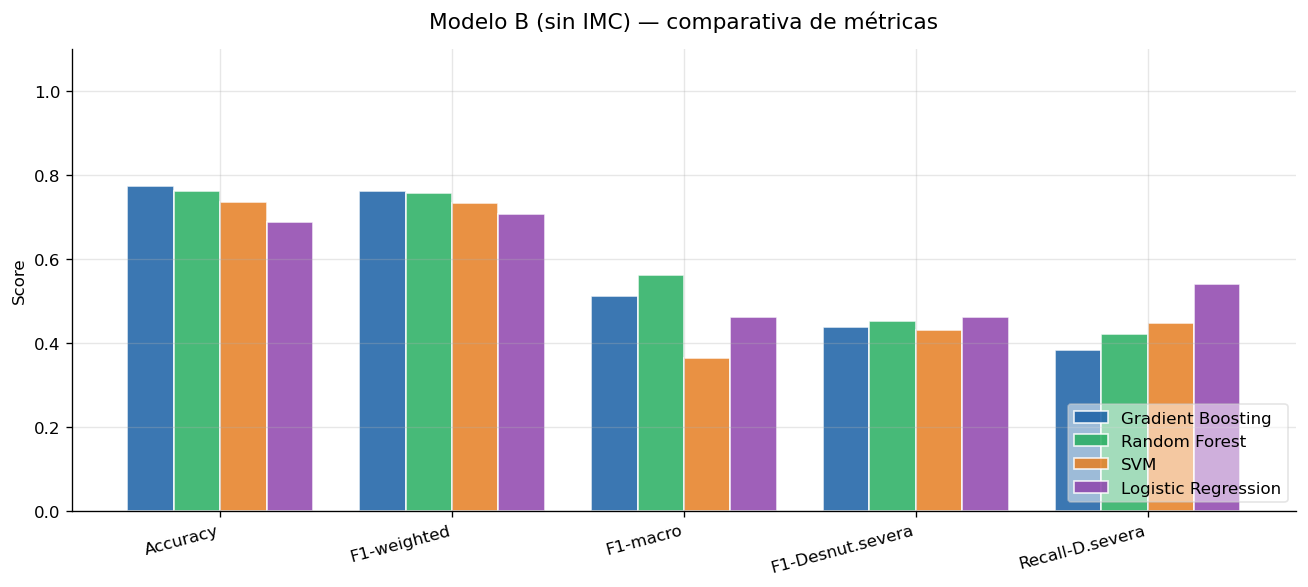

In [15]:
df_res_B, preds_B = evaluar_modelos(modelos_B, X_test_B, y_test_B,
                                     'Modelo B (sin IMC) — comparativa de métricas')

In [16]:
# Reporte detallado modelo B
for nombre, y_pred in preds_B.items():
    print(f'\n{"="*55}')
    print(f'  {nombre} — Modelo B (sin IMC)')
    print(f'{"="*55}')
    print(classification_report(y_test_B, y_pred, target_names=CLASES, zero_division=0))


  Logistic Regression — Modelo B (sin IMC)
                  precision    recall  f1-score   support

  Desnut. severa       0.40      0.54      0.46        76
Desnut. moderada       0.89      0.78      0.83       346
     Normal bajo       0.22      0.37      0.28        27
          Normal       0.38      0.33      0.35        33
       Sobrepeso       0.29      0.40      0.33         5
        Obesidad       0.33      1.00      0.50         1

        accuracy                           0.69       488
       macro avg       0.42      0.57      0.46       488
    weighted avg       0.74      0.69      0.71       488


  Random Forest — Modelo B (sin IMC)
                  precision    recall  f1-score   support

  Desnut. severa       0.48      0.42      0.45        76
Desnut. moderada       0.87      0.87      0.87       346
     Normal bajo       0.42      0.41      0.42        27
          Normal       0.53      0.79      0.63        33
       Sobrepeso       0.00      0.00      0

Mejor modelo B: Gradient Boosting | F1-weighted: 0.7603


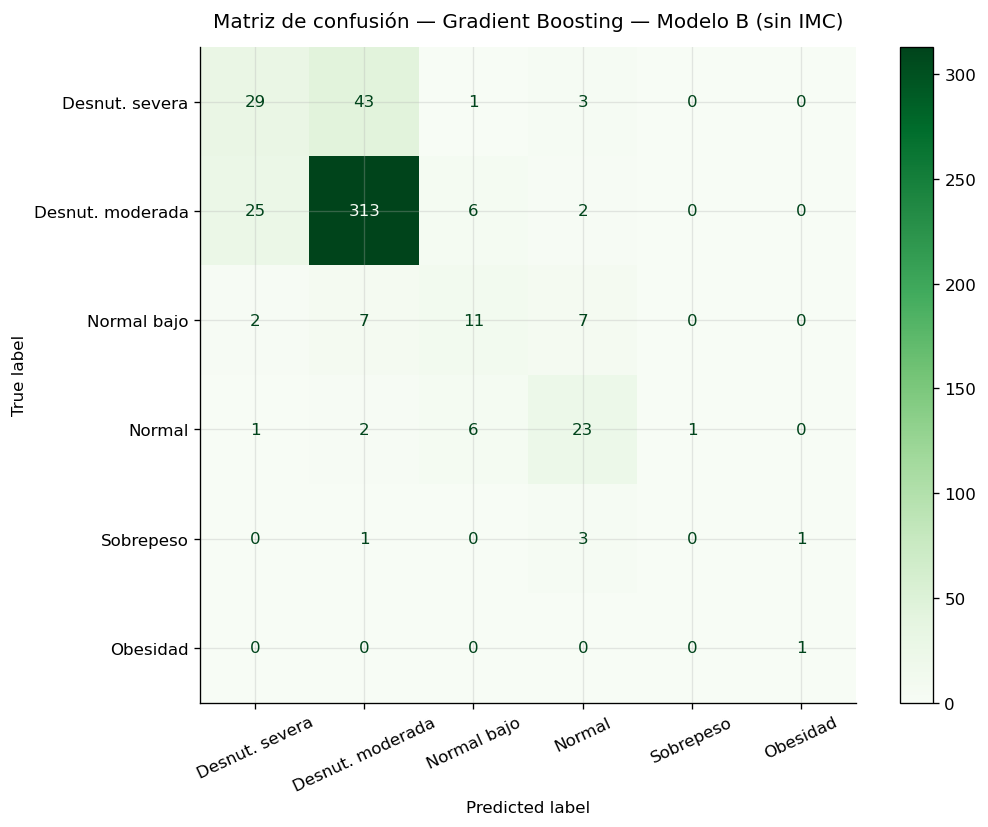


Desnutrición severa — Modelo B:
  Detectados : 29 (38.2%)
  No detectados FN: 47 (61.8%)


In [17]:
# Matriz de confusión mejor modelo B
mejor_B = df_res_B.iloc[0]['Modelo']
y_pred_mejor_B = preds_B[mejor_B]

print(f'Mejor modelo B: {mejor_B} | F1-weighted: {df_res_B.iloc[0]["F1-weighted"]:.4f}')

cm_B = confusion_matrix(y_test_B, y_pred_mejor_B)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm_B, display_labels=CLASES).plot(
    ax=ax, cmap='Greens', colorbar=True, xticks_rotation=25)
ax.set_title(f'Matriz de confusión — {mejor_B} — Modelo B (sin IMC)', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

detectados_B = cm_B[0, 0]
print(f'\nDesnutrición severa — Modelo B:')
print(f'  Detectados : {detectados_B} ({detectados_B/total_severos*100:.1f}%)')
print(f'  No detectados FN: {total_severos - detectados_B} ({(total_severos-detectados_B)/total_severos*100:.1f}%)')

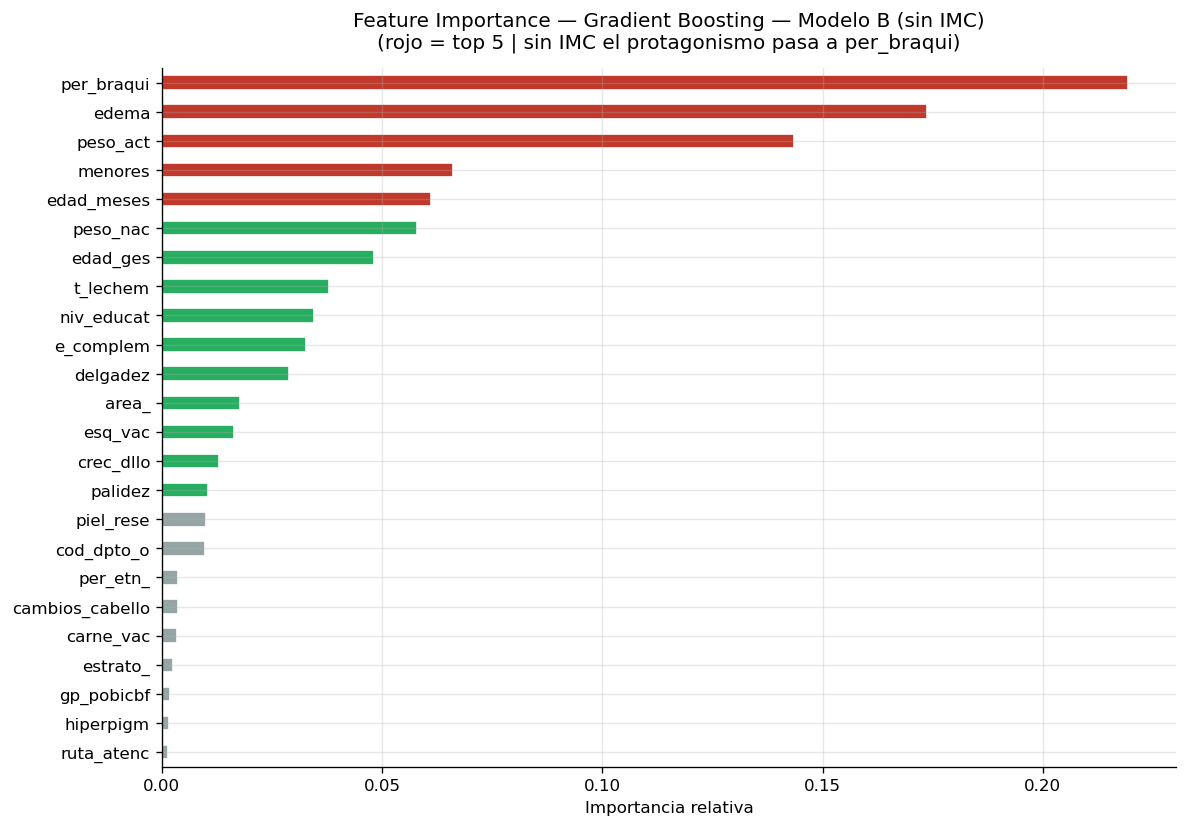

per_braqui         0.2193
edema              0.1738
peso_act           0.1435
menores            0.0662
edad_meses         0.0612
peso_nac           0.0580
edad_ges           0.0482
t_lechem           0.0380
niv_educat         0.0345
e_complem          0.0327
delgadez           0.0289
area_              0.0177
esq_vac            0.0163
crec_dllo          0.0129
palidez            0.0105
piel_rese          0.0101
cod_dpto_o         0.0099
per_etn_           0.0037
cambios_cabello    0.0036
carne_vac          0.0035
estrato_           0.0026
gp_pobicbf         0.0019
hiperpigm          0.0017
ruta_atenc         0.0013


In [18]:
# Feature importance Modelo B
modelo_mejor_B = modelos_B[mejor_B]

if hasattr(modelo_mejor_B, 'feature_importances_'):
    imp_B = pd.Series(modelo_mejor_B.feature_importances_, index=FEATURES_B)
elif hasattr(modelo_mejor_B, 'coef_'):
    imp_B = pd.Series(np.abs(modelo_mejor_B.coef_).mean(axis=0), index=FEATURES_B)
else:
    rf_B = modelos_B.get('Random Forest')
    imp_B = pd.Series(rf_B.feature_importances_, index=FEATURES_B)

imp_B = imp_B.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colores_fi_B = ['#c0392b' if i < 5 else '#27ae60' if i < 15 else '#95a5a6'
                for i in range(len(imp_B))]
imp_B[::-1].plot(kind='barh', ax=ax, color=colores_fi_B[::-1], edgecolor='white')
ax.set_title(f'Feature Importance — {mejor_B} — Modelo B (sin IMC)\n'
             f'(rojo = top 5 | sin IMC el protagonismo pasa a per_braqui)',
             fontsize=12, pad=12)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()
print(imp_B.round(4).to_string())

## 13. Comparativa final: Modelo A vs Modelo B

In [19]:
# Comparativa directa A vs B con el mismo algoritmo
print('COMPARATIVA FINAL — Modelo A (con IMC) vs Modelo B (sin IMC)')
print('='*65)
print(f'{"Métrica":<22} {"Modelo A (con IMC)":>20} {"Modelo B (sin IMC)":>20} {"Diferencia":>12}')
print('-'*65)

metricas_comp = ['Accuracy','F1-weighted','F1-macro','F1-Desnut.severa','Recall-D.severa']
fila_A = df_res_A[df_res_A['Modelo'] == mejor_A].iloc[0]
fila_B = df_res_B[df_res_B['Modelo'] == mejor_B].iloc[0]

for m in metricas_comp:
    val_A = fila_A[m]
    val_B = fila_B[m]
    diff  = val_A - val_B
    signo = '+' if diff >= 0 else ''
    print(f'{m:<22} {val_A:>20.4f} {val_B:>20.4f} {signo+str(round(diff,4)):>12}')

print()
print(f'Mejor algoritmo Modelo A: {mejor_A}')
print(f'Mejor algoritmo Modelo B: {mejor_B}')

COMPARATIVA FINAL — Modelo A (con IMC) vs Modelo B (sin IMC)
Métrica                  Modelo A (con IMC)   Modelo B (sin IMC)   Diferencia
-----------------------------------------------------------------
Accuracy                             0.8648               0.7725      +0.0923
F1-weighted                          0.8645               0.7603      +0.1042
F1-macro                             0.7420               0.5102      +0.2318
F1-Desnut.severa                     0.7183               0.4361      +0.2822
Recall-D.severa                      0.6711               0.3816      +0.2895

Mejor algoritmo Modelo A: Gradient Boosting
Mejor algoritmo Modelo B: Gradient Boosting


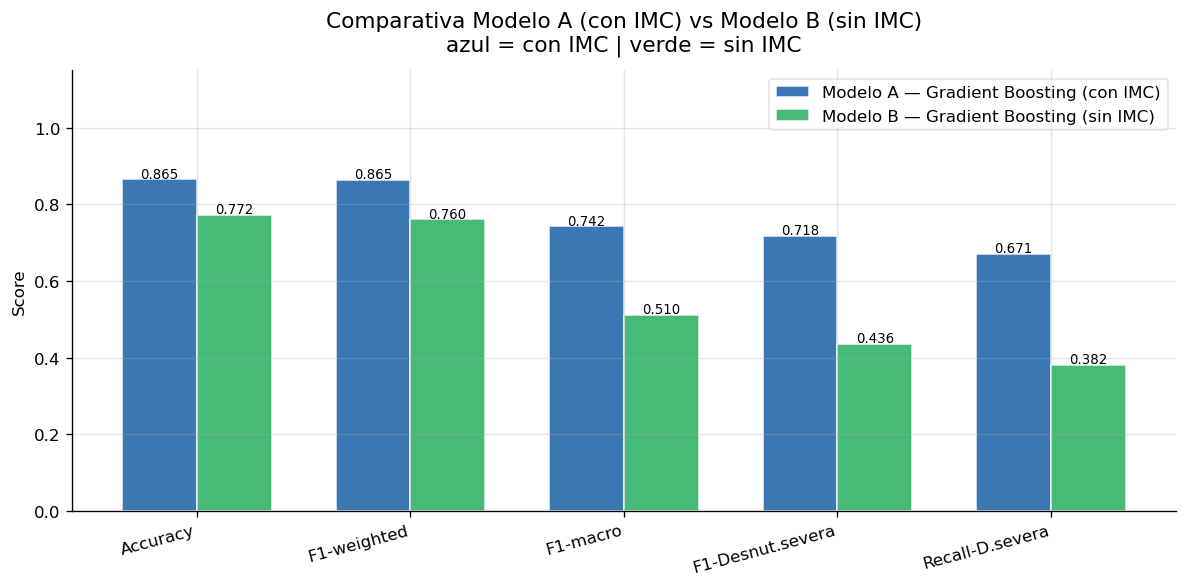


Interpretación:
  La diferencia entre ambos modelos indica el "costo" de no tener IMC.
  Si la diferencia es pequeña (<0.05), el Modelo B es viable en campo.
  Si es grande (>0.10), se recomienda priorizar el Modelo A en clínicas.


In [20]:
# Gráfico comparativo A vs B
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metricas_comp))
width = 0.35

vals_A = [fila_A[m] for m in metricas_comp]
vals_B = [fila_B[m] for m in metricas_comp]

bars_A = ax.bar(x - width/2, vals_A, width, label=f'Modelo A — {mejor_A} (con IMC)',
                color='#185fa5', edgecolor='white', alpha=0.85)
bars_B = ax.bar(x + width/2, vals_B, width, label=f'Modelo B — {mejor_B} (sin IMC)',
                color='#27ae60', edgecolor='white', alpha=0.85)

for bar in bars_A:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars_B:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metricas_comp, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Comparativa Modelo A (con IMC) vs Modelo B (sin IMC)\n'
             'azul = con IMC | verde = sin IMC', fontsize=13, pad=12)
ax.legend(framealpha=0.5)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  La diferencia entre ambos modelos indica el "costo" de no tener IMC.')
print('  Si la diferencia es pequeña (<0.05), el Modelo B es viable en campo.')
print('  Si es grande (>0.10), se recomienda priorizar el Modelo A en clínicas.')

## 14. Conclusiones y modelo seleccionado

### Dos modelos para dos contextos

| | Modelo A (con IMC) | Modelo B (sin IMC) |
|---|---|---|
| **Contexto** | Clínicas y hospitales | Promotores rurales / atención primaria |
| **Equipos necesarios** | Báscula + tallímetro | Solo cinta métrica |
| **Predictor principal** | IMC → per_braqui | per_braqui → peso_act |
| **Recomendado para** | Diagnóstico clínico formal | Detección temprana en campo |

### Hallazgos del modelado

| Aspecto | Resultado |
|---|---|
| Mejor algoritmo general | Gradient Boosting |
| Mejor predictor Modelo A | `imc` + `per_braqui` |
| Mejor predictor Modelo B | `per_braqui` + `peso_act` |
| Variables maternas con aporte | `t_lechem`, `niv_educat` |
| Variables sin aporte (ambos) | `menores`, `estrato_`, `crec_dllo` |
| Desbalance manejado con | SMOTE (solo en train) |
| Escalado aplicado | RobustScaler selectivo |

### Sobre el data leakage
- `zscore_pt` y `zscore_te` → excluidos del `dataset_ml.csv` en notebook 03 (leakage puro — definen directamente `clas_peso` según Res. 2465/2016)
- `imc` → incluido en Modelo A (medida clínica calculable), excluido en Modelo B (requiere equipos)

### Próximos pasos
- **Notebook 06:** Predicción temporal con `serie_temporal_mensual.csv`
- **Notebook 07:** Comparativa territorial Cesar vs La Guajira vs Magdalena
- **Opcional:** GridSearchCV para ajuste de hiperparámetros del mejor modelo